# Comparison of different regression models

On the diabetes dataset (scikit-learn), different lienar regression models are compared with non-linear models. Discuss the impact of the different loss functions for ``Lasso``, ``Ridge`` and ``ElasticNet``.

Discuss model efficiency and interpretation of various metrics.

On the data: The diabetes dataset is a classic "toy" dataset for regression benchmarks. It includes physiological features such as the age, bmi or some blood serum values (s1 - s6), all features are z-scaled. The target is a metric for the progression of the disease.


In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
print(X.head())

(442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# alpha (regularisation parameter in the loss function to penalise coefficients)
# hyperparameters on linear model will be optimised later
lin_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=ridge.alpha_),
    "Lasso": Lasso(alpha=lasso.alpha_),
    "ElasticNet": ElasticNet(alpha=elastic.alpha_, l1_ratio=0.9)
}

# hyperparameters for non-linear methods as suggested by Copilot
non_lin_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        random_state=42
        ),
    "HistGB": HistGradientBoostingRegressor(     
        learning_rate=0.05,
        max_depth=5,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        max_bins=255,
        early_stopping=True,
        random_state=42
        ),
    "SVR": SVR(    
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
        )
}

models = lin_models | non_lin_models # concatenation of two dicionaries

In [21]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import time

results_list = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    y_pred = model.predict(X_test)

    results = {
        "model": name,
        "test_RMSE": root_mean_squared_error(y_test, y_pred),
        "test_MAE": mean_absolute_error(y_test, y_pred),
        "test_R2": r2_score(y_test, y_pred),
        "fit_time_s": fit_time
    }
    results_list.append(results)

res_df = pd.DataFrame(results_list).sort_values("test_RMSE")
res_df

,model,test_RMSE,test_MAE,test_R2,fit_time_s
6,SVR,51.766236,41.243197,0.494212,0.005610
2,Lasso,52.917509,42.791794,0.471464,0.002007
5,HistGB,53.158562,43.494583,0.466638,0.088688
3,ElasticNet,53.389610,43.105052,0.461992,0.000998
1,Ridge,53.446112,42.996932,0.460852,0.002302
4,RandomForest,53.739698,43.535449,0.454913,0.217109
0,Linear,53.853446,42.794095,0.452603,0.003482


In [5]:
# investigate the linear model weights / coefficients

coef_df = pd.DataFrame({
    name: model.fit(X_train, y_train).coef_
    for name, model in lin_models.items()
}, index=X.columns)

print(coef_df)

         Linear       Ridge       Lasso  ElasticNet
age   37.904021   45.367377    0.000000   10.830921
sex -241.964362  -76.666086 -152.664779   -0.009514
bmi  542.428759  291.338832  552.697775   38.906865
bp   347.703844  198.995817  303.365158   28.779233
s1  -931.488846   -0.530310  -81.365007   10.372007
s2   518.062277  -28.577050   -0.000000    7.191892
s3   163.419983 -144.511905 -229.255776  -23.510979
s4   275.317902  119.260066    0.000000   25.627160
s5   736.198859  230.221608  447.919525   35.073745
s6    48.670657  112.149830   29.642617   24.071251


In [6]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridge = RidgeCV(alphas=[0.1, 1, 10])
lasso = LassoCV(cv=5)
elastic = ElasticNetCV(cv=5)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic.fit(X_train, y_train)

print("Best Ridge alpha:", ridge.alpha_)
print("Best Lasso alpha:", lasso.alpha_)
print("Best ElasticNet alpha:", elastic.alpha_)

Best Ridge alpha: 0.1
Best Lasso alpha: 0.07813983904476522
Best ElasticNet alpha: 0.004450901287065835


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lin_models["ElasticNet"].predict(X_test)

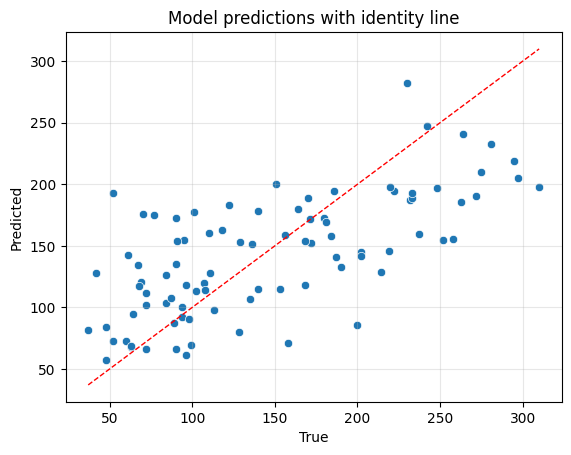

In [20]:
sns.scatterplot(x=y_test, y=y_pred)

# Identity line

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=1)

plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Model predictions with identity line")
plt.grid(alpha=0.3)
plt.show()
